Cross-dataset plots for Hi OOD-vs-Random-Shuffle analysis.

Reads the CSV tables produced by 01_cross_dataset_tables_hi.py and generates
paper-style figures for the datasets where the OOD inner holdout can be
reconstructed consistently from the Lo-Hi folds: DRD2, HIV and Sol.

KDR-Hi is excluded from this specific OOD-holdout vs random-shuffle comparison
because its outer training folds are restricted to 500 molecules and cannot be
reconstructed as train_i = F_a ∪ F_b.

All figures are saved to:
results/results_ood_vs_random_shuffle/hi/cross_dataset/figures/


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

In [2]:

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT.name != "drug-discovery-lohi" and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / "hi"
    / "cross_dataset"
)

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Figure dir:", FIG_DIR)

Project root: /home/f.capria/drug-discovery-lohi
Data dir: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset
Figure dir: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/figures


In [ ]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 10,
    "font.family": "sans-serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

PROTOCOL_COLORS = {
    "OOD holdout": "#2563EB",
    "Random shuffle": "#DC2626",
}
PROTOCOL_ORDER = ["OOD holdout", "Random shuffle"]

MODEL_MARKERS = {
    "Decision Tree": "o",
    "Logistic Regression": "s",
    "Linear SVM": "^",
}
MODEL_SHORT = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
}

DATASET_ORDER = ["drd2", "hiv", "sol"]
DATASET_LABELS = {
    "drd2": "DRD2",
    "hiv": "HIV",
    "sol": "Sol",
    "kdr": "KDR",  # kept only for safety, but excluded from this analysis
}

FP_MARKERS = {"ECFP4": "o", "MACCS": "s", "RDKit desc": "D"}


In [ ]:
print("Loading cross-dataset tables …")

summary = pd.read_csv(DATA_DIR / "cross_dataset_protocol_summary.csv")
delta = pd.read_csv(DATA_DIR / "cross_dataset_protocol_delta.csv")
complexity_all = pd.read_csv(DATA_DIR / "cross_dataset_complexity_all.csv")
overlap = pd.read_csv(DATA_DIR / "cross_dataset_feature_overlap.csv")
concentration = pd.read_csv(DATA_DIR / "cross_dataset_feature_concentration.csv")

VALID_DATASETS = set(DATASET_ORDER)

def _drop_excluded_datasets(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if "dataset" not in df.columns:
        return df

    before = len(df)
    df = df[df["dataset"].isin(VALID_DATASETS)].copy()
    after = len(df)

    if before != after:
        print(f"  {name}: dropped {before - after} rows from excluded datasets")

    return df

summary = _drop_excluded_datasets(summary, "summary")
delta = _drop_excluded_datasets(delta, "delta")
complexity_all = _drop_excluded_datasets(complexity_all, "complexity_all")
overlap = _drop_excluded_datasets(overlap, "overlap")
concentration = _drop_excluded_datasets(concentration, "concentration")

for name, df in {
    "summary": summary,
    "delta": delta,
    "complexity_all": complexity_all,
    "overlap": overlap,
    "concentration": concentration,
}.items():
    if "dataset" in df.columns:
        assert "kdr" not in set(df["dataset"]), f"KDR found in {name}"

print("OK: KDR excluded from all plotting tables.")

Loading cross-dataset tables …
  summary:       56 rows
  delta:         28 rows
  complexity:    168 rows
  overlap:       504 rows
  concentration: 168 rows


## Inner validation vs OOD test scatter (2×2 by dataset)

Saved: fig1_inner_vs_test_scatter.png


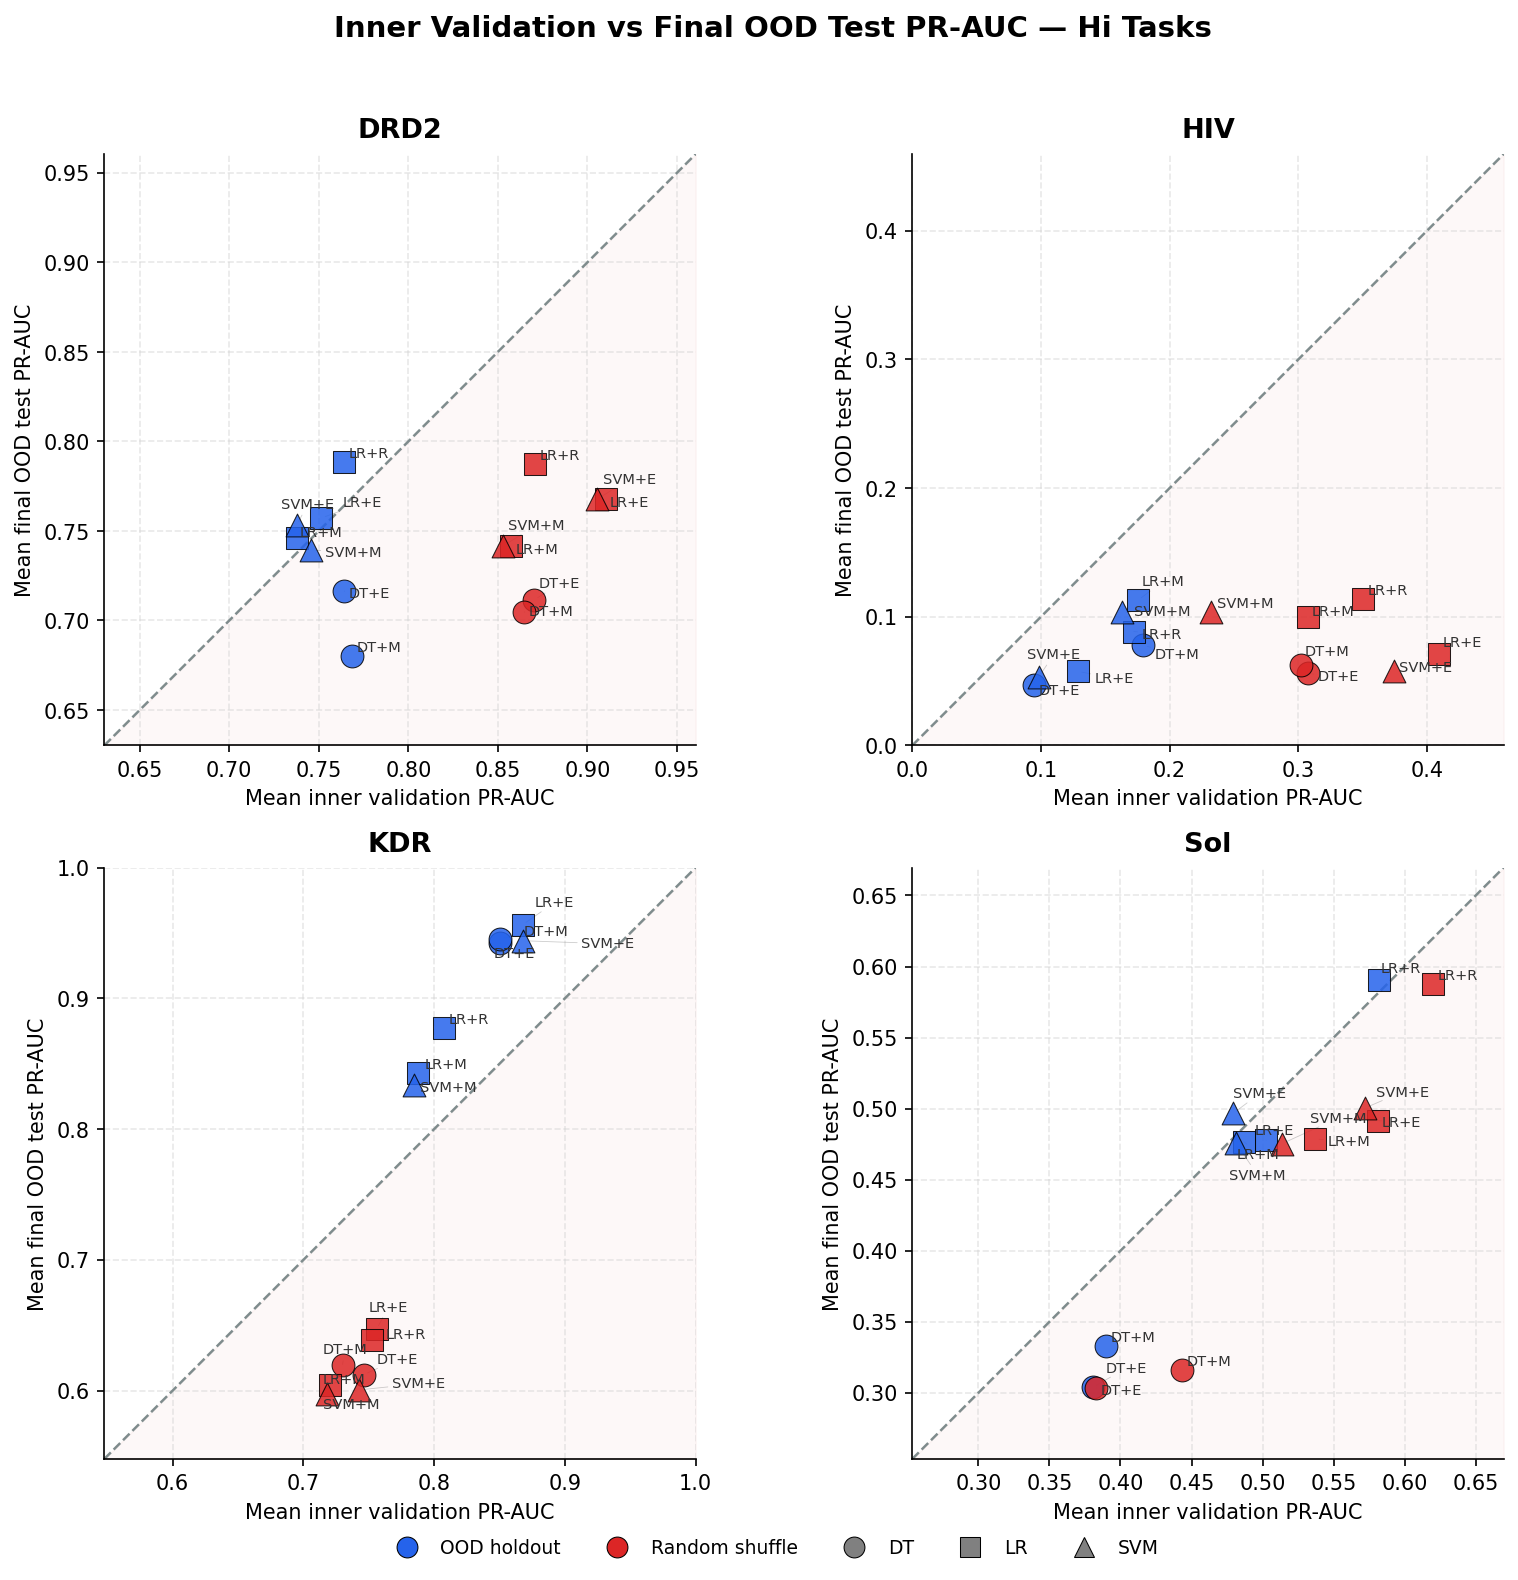

In [ ]:

def plot_figure1(summary: pd.DataFrame):
    datasets = [d for d in DATASET_ORDER if d in summary["dataset"].unique()]
    n = len(datasets)
    nrows, ncols = 1, n

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.4 * ncols, 4.4),
        squeeze=False,
    )

    for idx, dataset in enumerate(datasets):
        ax = axes[idx // ncols, idx % ncols]
        sub = summary[summary["dataset"] == dataset]

        # Determine axis limits
        all_vals = pd.concat([sub["inner_mean"], sub["test_mean"]])
        lo = max(0, all_vals.min() - 0.05)
        hi = min(1, all_vals.max() + 0.05)
        lims = [lo, hi]

        ax.set_axisbelow(True)
        ax.grid(True, linestyle="--", color="lightgrey", alpha=0.5, zorder=0)

        # Identity diagonal
        ax.plot(lims, lims, ls="--", lw=1.2, color="#7f8c8d", zorder=1)
        ax.fill_between(
            lims, lims, [lims[0], lims[0]],
            alpha=0.03, color="#c0392b", zorder=0,
        )

        for _, row in sub.iterrows():
            protocol = row["protocol"]
            model = row["model"]
            ax.scatter(
                row["inner_mean"],
                row["test_mean"],
                c=PROTOCOL_COLORS[protocol],
                marker=MODEL_MARKERS.get(model, "o"),
                s=120,
                edgecolors="black",
                linewidths=0.5,
                alpha=0.85,
                zorder=3,
            )

        try:
            from adjustText import adjust_text
            texts = []
            for _, row in sub.iterrows():
                ms = MODEL_SHORT.get(row["model"], row["model"][:2])
                fp_short = row["fingerprint"][:1] if row["fingerprint"] != "RDKit desc" else "R"
                label = f"{ms}+{fp_short}"
                texts.append(ax.text(
                    row["inner_mean"], row["test_mean"], label,
                    fontsize=7, color="#333333",
                ))
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="grey",
                                        lw=0.4, alpha=0.4))
        except ImportError:
            pass

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal")
        ax.set_xlabel("Mean inner validation PR-AUC", fontsize=10)
        ax.set_ylabel("Mean final OOD test PR-AUC", fontsize=10)
        ax.set_title(DATASET_LABELS.get(dataset, dataset),
                      fontsize=13, fontweight="bold", pad=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide unused panels
    for idx in range(len(datasets), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    # Shared legend
    protocol_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markersize=10, markeredgecolor="black", markeredgewidth=0.5,
               label=p)
        for p, c in PROTOCOL_COLORS.items()
    ]
    model_handles = [
        Line2D([0], [0], marker=m, color="w", markerfacecolor="grey",
               markersize=10, markeredgecolor="black", markeredgewidth=0.5,
               label=MODEL_SHORT[name])
        for name, m in MODEL_MARKERS.items()
    ]
    fig.legend(
        handles=protocol_handles + model_handles,
        loc="lower center", ncol=5, fontsize=9,
        bbox_to_anchor=(0.5, -0.02), frameon=False,
    )

    fig.suptitle(
        "Inner Validation vs Final OOD Test PR-AUC — Hi Tasks",
        fontsize=14, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    fname = FIG_DIR / "fig1_inner_vs_test_scatter.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)
    
plot_figure1(summary)

## Protocol delta heatmap

Saved: fig2_protocol_delta_heatmap.png


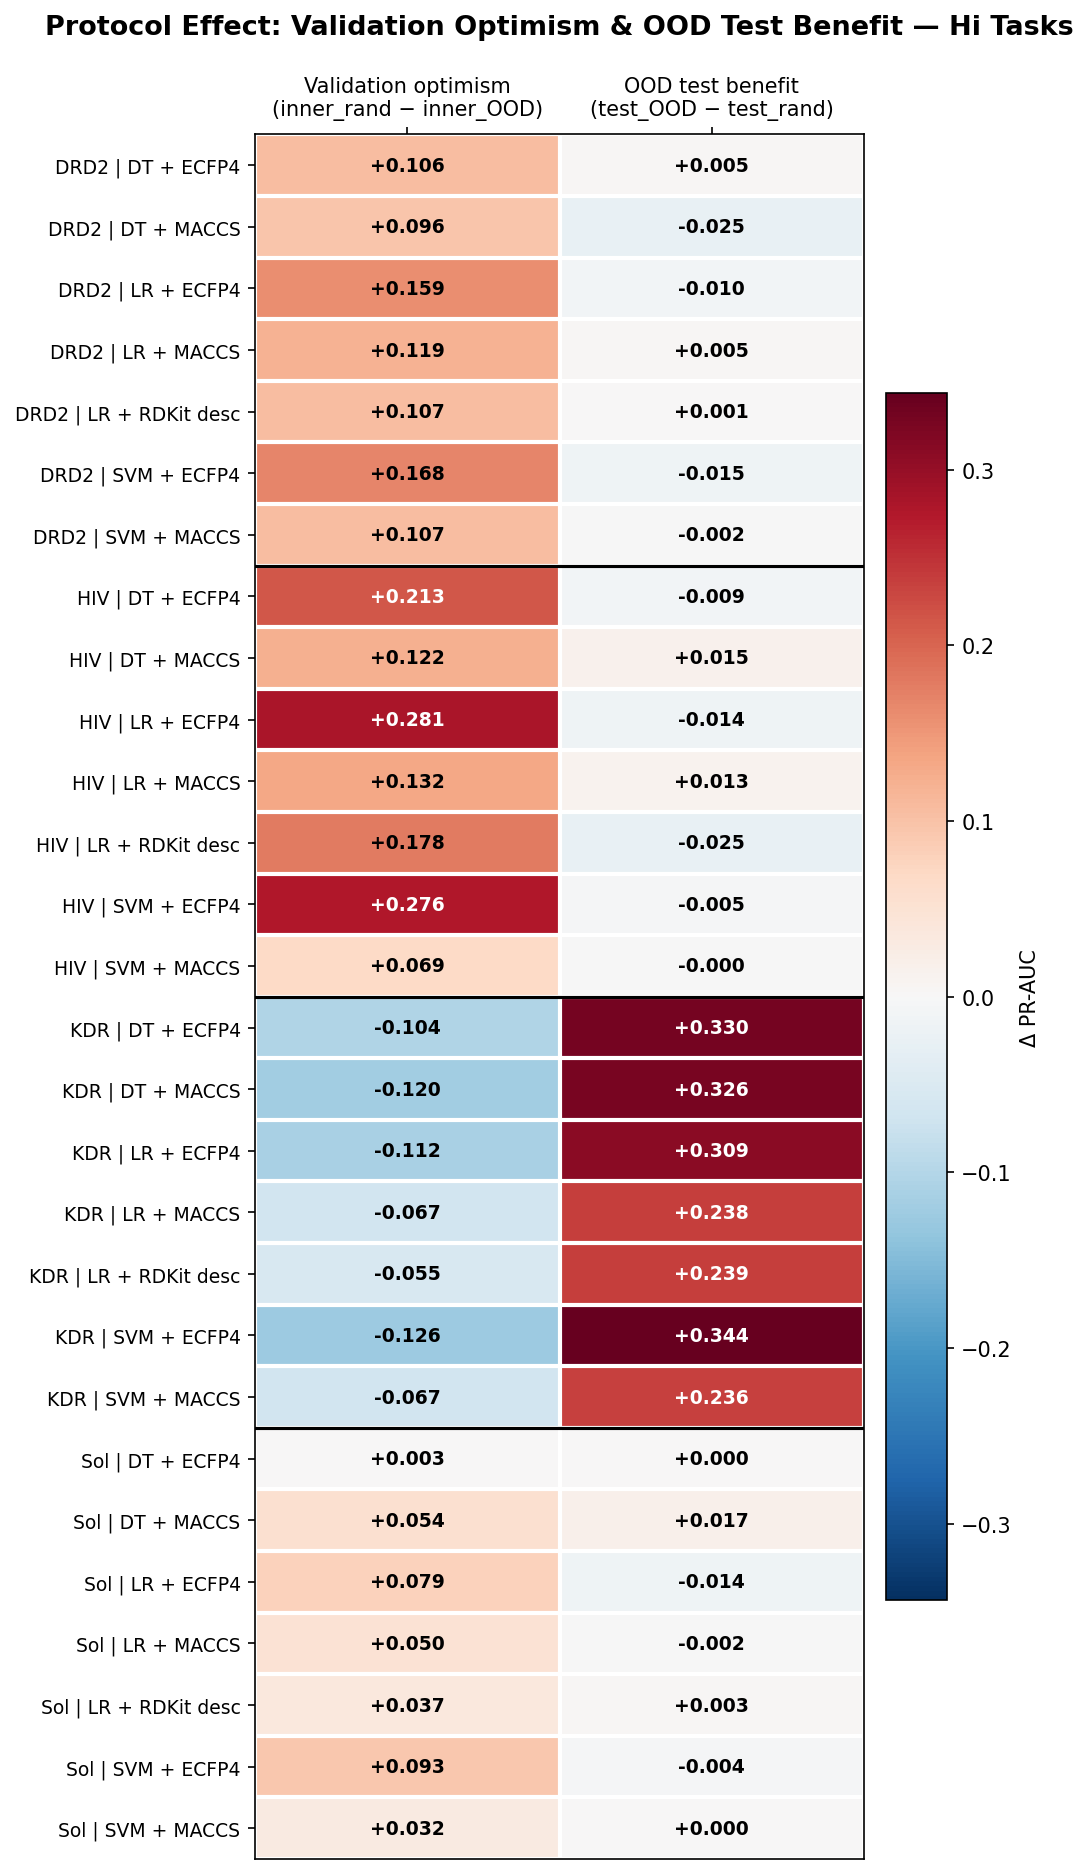

In [ ]:

def plot_figure2(delta: pd.DataFrame):
    if len(delta) == 0:
        print("No delta data — skipping Figure 2.")
        return

    plot_df = delta.copy()
    plot_df["experiment"] = (
        plot_df["dataset_label"] + " | "
        + plot_df["model_short"] + " + "
        + plot_df["fingerprint"]
    )

    # Sort
    for col, order in [("dataset", {"drd2": 0, "hiv": 1, "sol": 2, "kdr": 99}),
                       ("model", {"Decision Tree": 0, "Logistic Regression": 1, "Linear SVM": 2}),
                       ("fingerprint", {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2})]:
        plot_df[f"_ord_{col}"] = plot_df[col].map(order)
    plot_df = plot_df.sort_values(
        ["_ord_dataset", "_ord_model", "_ord_fingerprint"]
    ).reset_index(drop=True)

    experiments = plot_df["experiment"].tolist()
    metrics = ["delta_inner_optimism", "delta_test_benefit"]
    metric_labels = {
        "delta_inner_optimism": "Validation optimism\n(inner_rand − inner_OOD)",
        "delta_test_benefit": "OOD test benefit\n(test_OOD − test_rand)",
    }

    mat = plot_df[metrics].values
    vmax = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.001)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, max(4, 0.45 * len(experiments))))
    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_yticks(range(len(experiments)))
    ax.set_yticklabels(experiments, fontsize=9)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([metric_labels[m] for m in metrics], fontsize=10)
    ax.xaxis.tick_top()

    for i in range(len(experiments)):
        for j in range(len(metrics)):
            val = mat[i, j]
            if np.isnan(val):
                continue
            text_color = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center",
                    fontsize=9, fontweight="bold", color=text_color)

    # Horizontal separators between datasets
    prev_ds = plot_df.iloc[0]["dataset"]
    for i in range(1, len(plot_df)):
        if plot_df.iloc[i]["dataset"] != prev_ds:
            ax.axhline(i - 0.5, color="black", linewidth=1.5, zorder=5)
            prev_ds = plot_df.iloc[i]["dataset"]

    ax.set_xticks(np.arange(-0.5, len(metrics), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(experiments), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False, top=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
    cbar.set_label("Δ PR-AUC", fontsize=10)

    ax.set_title(
        "Protocol Effect: Validation Optimism & OOD Test Benefit — Hi Tasks",
        fontsize=13, fontweight="bold", pad=20,
    )

    fig.tight_layout()
    fname = FIG_DIR / "fig2_protocol_delta_heatmap.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)

plot_figure2(delta)

## Model complexity by protocol

Saved: fig3_complexity_protocol_logratio_heatmap.png


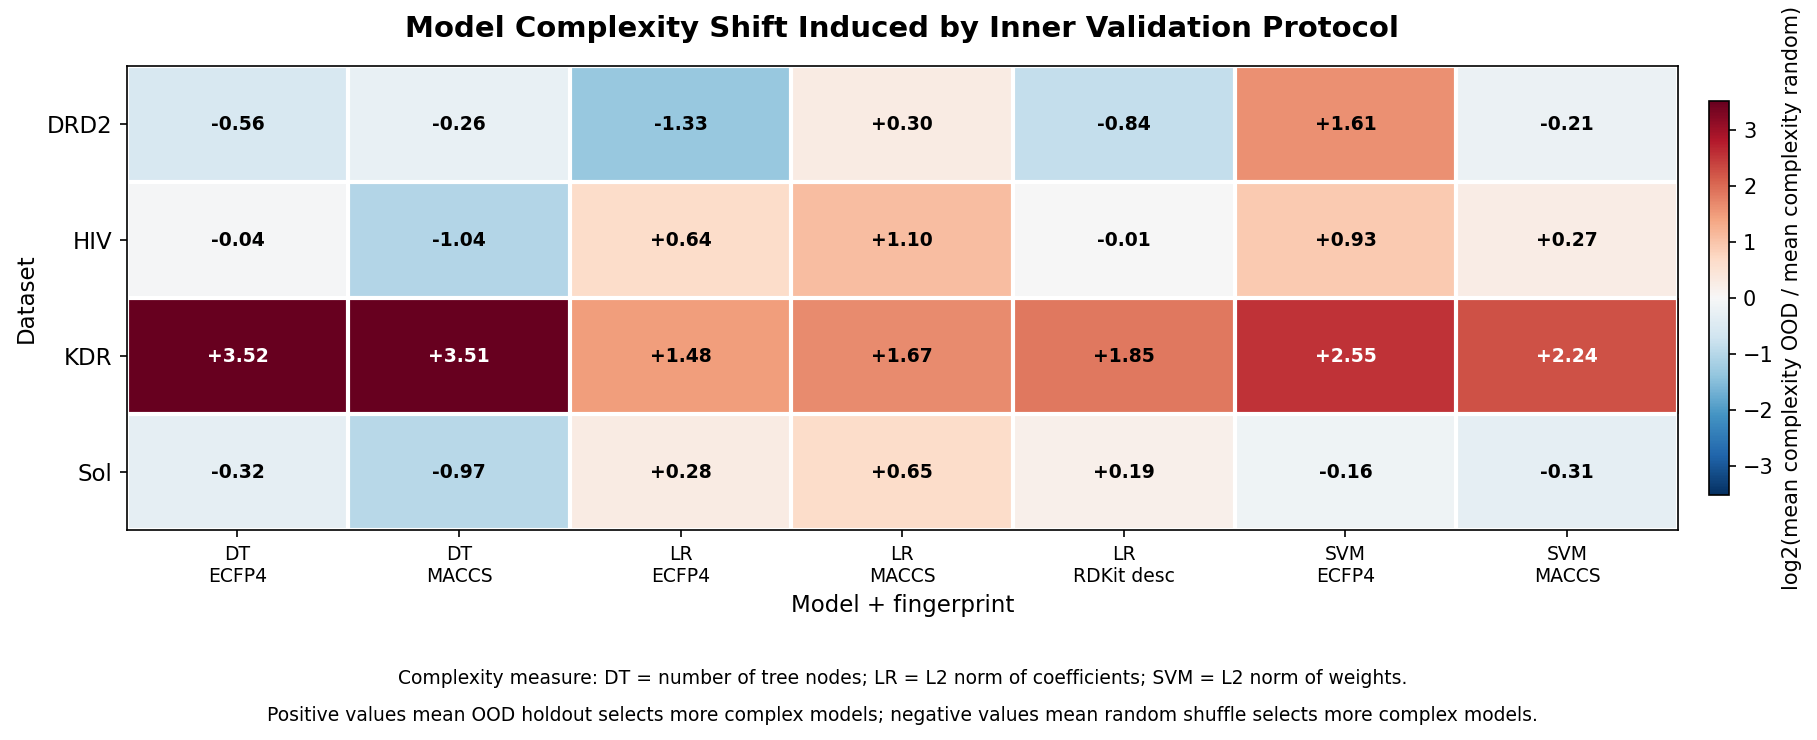

In [ ]:
def plot_figure3(complexity_all: pd.DataFrame):
    if len(complexity_all) == 0:
        print("No complexity data — skipping Figure 3.")
        return

    model_configs = [
        {
            "model": "Decision Tree",
            "model_short": "DT",
            "complexity_col": "n_nodes",
            "complexity_label": "tree nodes",
        },
        {
            "model": "Logistic Regression",
            "model_short": "LR",
            "complexity_col": "l2_norm",
            "complexity_label": "coefficient L2 norm",
        },
        {
            "model": "Linear SVM",
            "model_short": "SVM",
            "complexity_col": "l2_norm",
            "complexity_label": "weight L2 norm",
        },
    ]

    rows = []

    for cfg in model_configs:
        model = cfg["model"]
        complexity_col = cfg["complexity_col"]

        if model not in complexity_all["model"].unique():
            continue

        if complexity_col not in complexity_all.columns:
            continue

        sub = complexity_all[
            complexity_all["model"] == model
        ].copy()

        sub = sub.dropna(subset=[complexity_col])

        if len(sub) == 0:
            continue

        grouped = (
            sub
            .groupby(["dataset", "fingerprint", "protocol"], as_index=False)
            [complexity_col]
            .mean()
        )

        pivot = grouped.pivot_table(
            index=["dataset", "fingerprint"],
            columns="protocol",
            values=complexity_col,
        )

        for (dataset, fingerprint), vals in pivot.iterrows():
            if "OOD holdout" not in vals or "Random shuffle" not in vals:
                continue

            ood_value = vals["OOD holdout"]
            random_value = vals["Random shuffle"]

            if pd.isna(ood_value) or pd.isna(random_value):
                continue

            eps = 1e-12
            log2_ratio = np.log2((ood_value + eps) / (random_value + eps))

            rows.append({
                "dataset": dataset,
                "dataset_label": DATASET_LABELS.get(dataset, dataset),
                "fingerprint": fingerprint,
                "model": model,
                "model_short": cfg["model_short"],
                "complexity_label": cfg["complexity_label"],
                "ood_complexity_mean": ood_value,
                "random_complexity_mean": random_value,
                "log2_ood_over_random": log2_ratio,
            })

    plot_df = pd.DataFrame(rows)

    if len(plot_df) == 0:
        print("No matched OOD/random complexity data — skipping Figure 3.")
        return

    # Stable ordering
    dataset_order = {"drd2": 0, "hiv": 1, "sol": 2, "kdr": 99}    model_order = {"DT": 0, "LR": 1, "SVM": 2}
    fp_order = {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2}

    plot_df["_dataset_order"] = plot_df["dataset"].map(dataset_order)
    plot_df["_model_order"] = plot_df["model_short"].map(model_order)
    plot_df["_fp_order"] = plot_df["fingerprint"].map(fp_order)

    plot_df = plot_df.sort_values(
        ["_dataset_order", "_model_order", "_fp_order"]
    ).reset_index(drop=True)

    plot_df["column"] = (
        plot_df["model_short"] + "\n" + plot_df["fingerprint"]
    )

    heatmap = plot_df.pivot_table(
        index="dataset_label",
        columns="column",
        values="log2_ood_over_random",
    )

    # Reorder rows and columns explicitly
    row_order = [
        DATASET_LABELS[d]
        for d in DATASET_ORDER
        if DATASET_LABELS[d] in heatmap.index
    ]

    col_order = list(dict.fromkeys(plot_df["column"].tolist()))

    heatmap = heatmap.reindex(index=row_order, columns=col_order)

    values = heatmap.values
    vmax = np.nanmax(np.abs(values))

    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)

    im = ax.imshow(
        values,
        aspect="auto",
        cmap="RdBu_r",
        norm=norm,
    )

    ax.set_xticks(np.arange(len(heatmap.columns)))
    ax.set_xticklabels(heatmap.columns, fontsize=9)

    ax.set_yticks(np.arange(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index, fontsize=11)

    ax.set_title(
        "Model Complexity Shift Induced by Inner Validation Protocol",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    ax.set_xlabel("Model + fingerprint", fontsize=11)
    ax.set_ylabel("Dataset", fontsize=11)

    # Cell labels
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]

            if np.isnan(val):
                label = "NA"
                color = "black"
            else:
                label = f"{val:+.2f}"
                color = "white" if abs(val) > 0.55 * vmax else "black"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=color,
            )

    # Grid lines
    ax.set_xticks(np.arange(-0.5, len(heatmap.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heatmap.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label(
        "log2(mean complexity OOD / mean complexity random)",
        fontsize=10,
    )

    ax.text(
        0.5,
        -0.30,
        "Complexity measure: DT = number of tree nodes; LR = coefficient-vector L2 norm; SVM = weight-vector L2 norm.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    ax.text(
        0.5,
        -0.38,
        "Positive values indicate higher average complexity under OOD holdout; negative values indicate higher average complexity under random shuffle.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    fname = FIG_DIR / "fig3_complexity_protocol_logratio_heatmap.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")

    print(f"Saved: {fname.name}")

    plt.show()
    plt.close(fig)
    
plot_figure3(complexity_all)

## Top-k feature overlap between OOD and Random

Saved: fig4_top50_feature_overlap_heatmap.png


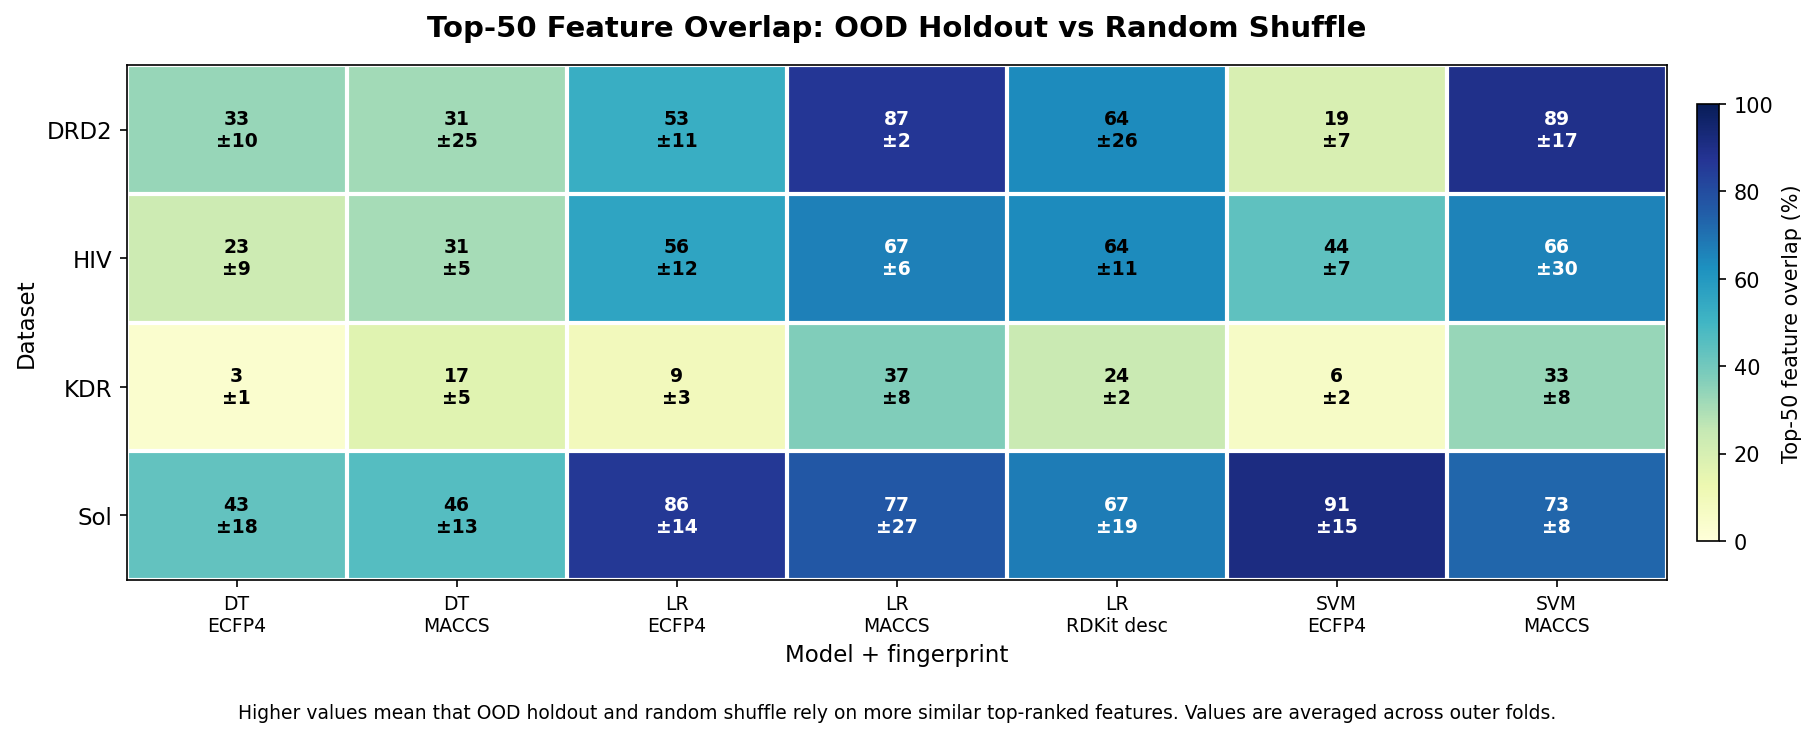

In [ ]:
def plot_figure4(overlap: pd.DataFrame, plot_top_k: int = 50):
    if len(overlap) == 0:
        print("No overlap data — skipping Figure 4.")
        return

    required_cols = ["dataset", "model", "fingerprint", "fold", "top_k", "overlap_percent"]
    missing = [c for c in required_cols if c not in overlap.columns]
    if missing:
        print(f"Missing required columns in overlap table: {missing}")
        return

    plot_df = overlap.copy()

    model_short_map = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
        "decision_tree": "DT",
        "lr": "LR",
        "svm": "SVM",
        "svm_linear": "SVM",
    }

    fp_map = {
        "ecfp4": "ECFP4",
        "maccs": "MACCS",
        "rdkit_desc": "RDKit desc",
        "ECFP4": "ECFP4",
        "MACCS": "MACCS",
        "RDKit desc": "RDKit desc",
    }

    plot_df["model_short"] = (
        plot_df["model"]
        .map(model_short_map)
        .fillna(plot_df["model"].astype(str))
    )

    plot_df["fingerprint"] = (
        plot_df["fingerprint"]
        .map(fp_map)
        .fillna(plot_df["fingerprint"].astype(str))
    )

    available_k = sorted(plot_df["top_k"].dropna().unique())

    if plot_top_k not in available_k:
        print(
            f"Requested top-{plot_top_k}, but available top-k values are: {available_k}. "
            f"Using top-{available_k[0]} instead."
        )
        plot_top_k = available_k[0]

    plot_df = plot_df[plot_df["top_k"] == plot_top_k].copy()

    if len(plot_df) == 0:
        print(f"No overlap data for top-{plot_top_k} — skipping Figure 4.")
        return

    agg = (
        plot_df
        .groupby(["dataset", "model_short", "fingerprint"], as_index=False)
        .agg(
            overlap_mean=("overlap_percent", "mean"),
            overlap_std=("overlap_percent", "std"),
        )
    )

    dataset_order = {"drd2": 0, "hiv": 1, "sol": 2, "kdr": 99}    model_order = {"DT": 0, "LR": 1, "SVM": 2}
    fp_order = {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2}

    agg["_dataset_order"] = agg["dataset"].map(dataset_order)
    agg["_model_order"] = agg["model_short"].map(model_order)
    agg["_fp_order"] = agg["fingerprint"].map(fp_order)

    agg = agg.sort_values(
        ["_dataset_order", "_model_order", "_fp_order"]
    ).reset_index(drop=True)

    agg["dataset_label"] = agg["dataset"].map(DATASET_LABELS).fillna(agg["dataset"])
    agg["column"] = agg["model_short"] + "\n" + agg["fingerprint"]

    heatmap = agg.pivot_table(
        index="dataset_label",
        columns="column",
        values="overlap_mean",
    )

    std_map = agg.pivot_table(
        index="dataset_label",
        columns="column",
        values="overlap_std",
    )

    row_order = [
        DATASET_LABELS[d]
        for d in DATASET_ORDER
        if DATASET_LABELS[d] in heatmap.index
    ]

    col_order = list(dict.fromkeys(agg["column"].tolist()))

    heatmap = heatmap.reindex(index=row_order, columns=col_order)
    std_map = std_map.reindex(index=row_order, columns=col_order)

    values = heatmap.values

    fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)

    im = ax.imshow(
        values,
        aspect="auto",
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
    )

    ax.set_xticks(np.arange(len(heatmap.columns)))
    ax.set_xticklabels(heatmap.columns, fontsize=9)

    ax.set_yticks(np.arange(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index, fontsize=11)

    ax.set_xlabel("Model + fingerprint", fontsize=11)
    ax.set_ylabel("Dataset", fontsize=11)

    ax.set_title(
        f"Top-{plot_top_k} Feature Overlap: OOD Holdout vs Random Shuffle",
        fontsize=14,
        fontweight="bold",
        pad=14,
    )

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]

            if np.isnan(val):
                label = "NA"
                color = "black"
            else:
                std_val = std_map.values[i, j]

                if np.isnan(std_val):
                    label = f"{val:.0f}"
                else:
                    label = f"{val:.0f}\n±{std_val:.0f}"

                color = "white" if val > 65 else "black"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=color,
            )

    ax.set_xticks(np.arange(-0.5, len(heatmap.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heatmap.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label(f"Top-{plot_top_k} feature overlap (%)", fontsize=10)

    ax.text(
        0.5,
        -0.24,
        "Higher values mean that OOD holdout and random shuffle rely on more similar top-ranked features. "
        "Values are averaged across outer folds; for fingerprints with fewer than k features, the effective available k is used.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    fname = FIG_DIR / f"fig4_top{plot_top_k}_feature_overlap_heatmap.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")

    print(f"Saved: {fname.name}")

    plt.show()
    plt.close(fig)
    
plot_figure4(overlap, plot_top_k=50)

## Importance concentration summary

Saved: fig5_feature_importance_concentration_curves.png


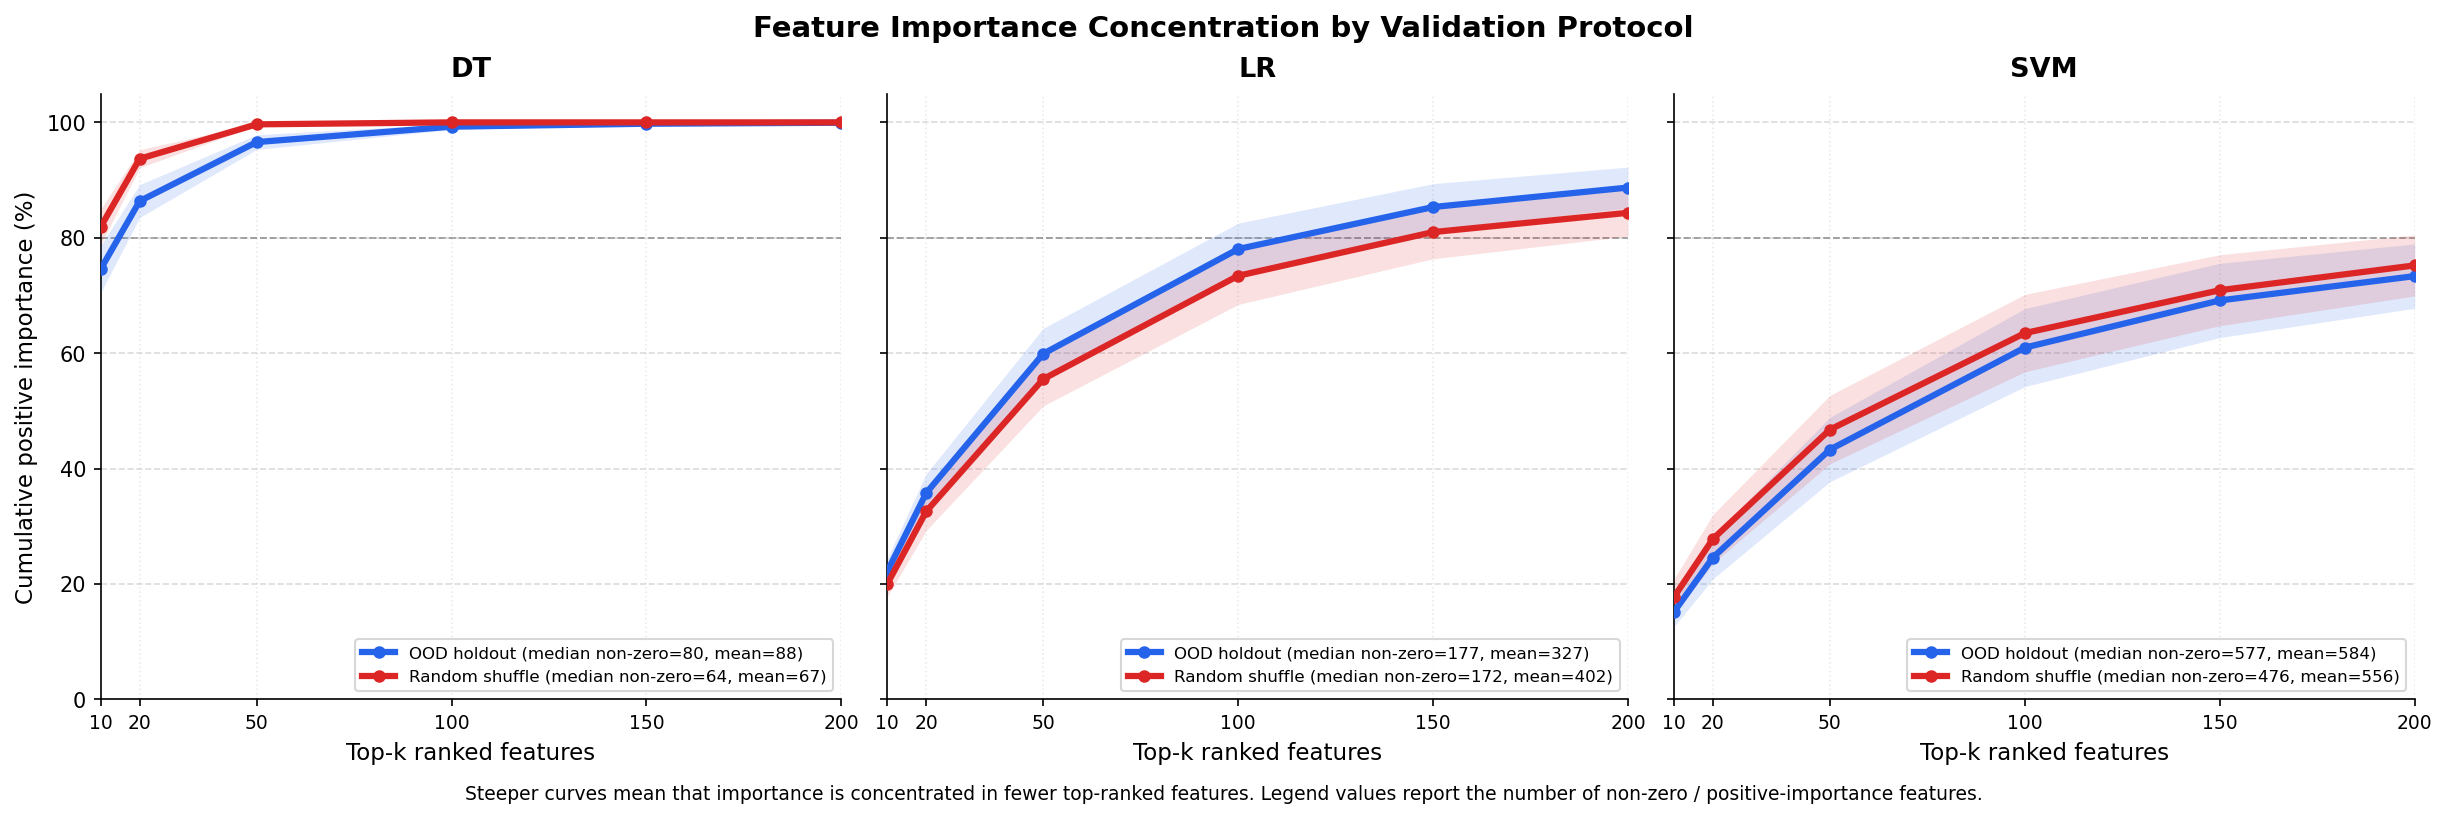

In [ ]:
def plot_figure5(concentration: pd.DataFrame):
    if len(concentration) == 0:
        print("No concentration data — skipping Figure 5.")
        return

    required_cols = ["dataset", "model", "fingerprint", "protocol", "fold", "n_nonzero"]
    missing = [c for c in required_cols if c not in concentration.columns]
    if missing:
        print(f"Missing required columns in concentration table: {missing}")
        return

    frac_cols = [
        c for c in concentration.columns
        if c.startswith("fraction_top_")
    ]

    if not frac_cols:
        print("No fraction_top_* columns — skipping Figure 5.")
        return

    frac_cols = sorted(frac_cols, key=lambda c: int(c.split("_")[-1]))
    top_k_values = np.array([int(c.split("_")[-1]) for c in frac_cols])

    plot_df = concentration.copy()

    model_short_map = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
        "decision_tree": "DT",
        "lr": "LR",
        "svm": "SVM",
        "svm_linear": "SVM",
    }

    if "model_short" not in plot_df.columns:
        plot_df["model_short"] = (
            plot_df["model"]
            .map(model_short_map)
            .fillna(plot_df["model"].astype(str))
        )
    else:
        plot_df["model_short"] = (
            plot_df["model_short"]
            .map(model_short_map)
            .fillna(plot_df["model_short"].astype(str))
        )

    model_order = ["DT", "LR", "SVM"]
    available_models = [
        m for m in model_order
        if m in plot_df["model_short"].unique()
    ]

    if not available_models:
        print("No recognized models in concentration table — skipping Figure 5.")
        return

    fig, axes = plt.subplots(
        1,
        len(available_models),
        figsize=(5.4 * len(available_models), 4.8),
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )

    for mi, model_short in enumerate(available_models):
        ax = axes[0, mi]
        sub_model = plot_df[plot_df["model_short"] == model_short].copy()

        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.45)
        ax.grid(axis="x", linestyle=":", alpha=0.25)

        for protocol in PROTOCOL_ORDER:
            sub_protocol = sub_model[sub_model["protocol"] == protocol].copy()

            if len(sub_protocol) == 0:
                continue

            mean_vals = np.array([
                sub_protocol[c].mean() * 100
                for c in frac_cols
            ])

            sem_vals = np.array([
                sub_protocol[c].std() * 100 / np.sqrt(sub_protocol[c].notna().sum())
                if sub_protocol[c].notna().sum() > 1 else 0.0
                for c in frac_cols
            ])

            median_nonzero = sub_protocol["n_nonzero"].median()
            mean_nonzero = sub_protocol["n_nonzero"].mean()

            label = (
                f"{protocol} "
                f"(median non-zero={median_nonzero:.0f}, mean={mean_nonzero:.0f})"
            )

            ax.plot(
                top_k_values,
                mean_vals,
                color=PROTOCOL_COLORS[protocol],
                linewidth=3.0,
                marker="o",
                markersize=5,
                label=label,
                zorder=4,
            )

            ax.fill_between(
                top_k_values,
                mean_vals - sem_vals,
                mean_vals + sem_vals,
                color=PROTOCOL_COLORS[protocol],
                alpha=0.14,
                linewidth=0,
                zorder=3,
            )

        ax.axhline(
            80,
            color="grey",
            linestyle="--",
            linewidth=0.9,
            alpha=0.7,
        )

        ax.set_title(
            model_short,
            fontsize=13,
            fontweight="bold",
            pad=8,
        )

        ax.set_xlabel("Top-k ranked features", fontsize=11)
        ax.set_ylim(0, 105)
        ax.set_xlim(top_k_values.min(), top_k_values.max())
        ax.set_xticks(top_k_values)
        ax.set_xticklabels([str(k) for k in top_k_values], fontsize=9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.legend(
            loc="lower right",
            fontsize=8,
            frameon=True,
            framealpha=0.9,
            edgecolor="lightgrey",
        )

    axes[0, 0].set_ylabel(
        "Cumulative positive importance (%)",
        fontsize=11,
        weight="medium",
    )

    fig.suptitle(
        "Feature Importance Concentration by Validation Protocol",
        fontsize=14,
        fontweight="bold",
        y=1.05,
    )

    fig.text(
        0.5,
        -0.02,
        "Steeper curves indicate stronger concentration among top-ranked features. "
        "Legend values report non-zero / positive-importance features. "
        "DT uses permutation importance; LR/SVM use coefficient-based importance, so comparisons are within model family.",
        ha="center",
        va="top",
        fontsize=9,
    )

    fname = FIG_DIR / "fig5_feature_importance_concentration_curves.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")

    print(f"Saved: {fname.name}")

    plt.show()
    plt.close(fig)
    
plot_figure5(concentration)